### Implement a Gaussian Naive Bayes classifier

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming that all features are independent of each other and normally distributed. It's often a good baseline model due to its simplicity and speed.

In [25]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training sets
gnb.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = gnb.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


### Generate a Confusion Matrix

A Confusion Matrix helps visualize the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. For our scouting context:

*   **True Positive (TP):** Player predicted to play 5+ years, and actually does. (Correctly identified talent)
*   **True Negative (TN):** Player predicted not to play 5+ years, and actually doesn't. (Correctly identified 'bust')
*   **False Positive (FP):** Player predicted to play 5+ years, but actually doesn't. (A 'bust' falsely identified as talent - a wasted draft pick)
*   **False Negative (FN):** Player predicted not to play 5+ years, but actually does. (Missed talent - a player passed over who succeeded)

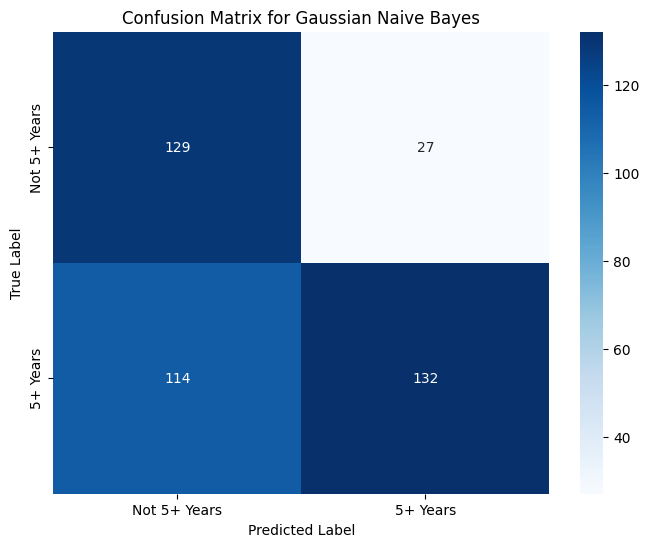

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not 5+ Years', '5+ Years'],
            yticklabels=['Not 5+ Years', '5+ Years'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Calculate Precision and Recall

Precision and Recall are crucial business-relevant metrics for our scouting scenario:

*   **Precision (Minimize False Positives: 'busts'):** Of all the players we *predicted* would play 5+ years, how many actually did? High precision means fewer wasted draft picks (fewer 'busts').
    `Precision = TP / (TP + FP)`

*   **Recall (Minimize False Negatives: missed talent):** Of all the players who *actually* played 5+ years, how many did we correctly identify? High recall means we are less likely to miss out on future stars.
    `Recall = TP / (TP + FN)`

In [27]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/extracted_nba_playersr_data.csv')

# Display the first 5 rows and confirm 'target_5yrs' column
display(df.head())

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


The `target_5yrs` column is present, which is our classification target. Now, let's preprocess the features to ensure compatibility with Gaussian Naive Bayes, which typically works well with continuous features. We'll also separate the features (X) from the target (y).

In [28]:
# Identify features and target
# Drop the target variable itself from features (X)
# All other columns are numerical and will be used as features for the Gaussian Naive Bayes model.

X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

# Display the first few rows of features (X) and target (y)
print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,fg,3p,ft,reb,ast,stl,blk,tov,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,216.0,0.391304



Target (y) head:


,target_5yrs
0,0
1,0
2,0
3,1
4,1


Next, we will split the data into training and testing sets to evaluate our model's performance unbiasedly.

In [29]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 938 samples
Testing set size: 402 samples


### Implement a Gaussian Naive Bayes classifier

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming that all features are independent of each other and normally distributed. It's often a good baseline model due to its simplicity and speed.

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training sets
gnb.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = gnb.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


### Generate a Confusion Matrix

A Confusion Matrix helps visualize the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. For our scouting context:

*   **True Positive (TP):** Player predicted to play 5+ years, and actually does. (Correctly identified talent)
*   **True Negative (TN):** Player predicted not to play 5+ years, and actually doesn't. (Correctly identified 'bust')
*   **False Positive (FP):** Player predicted to play 5+ years, but actually doesn't. (A 'bust' falsely identified as talent - a wasted draft pick)
*   **False Negative (FN):** Player predicted not to play 5+ years, but actually does. (Missed talent - a player passed over who succeeded)

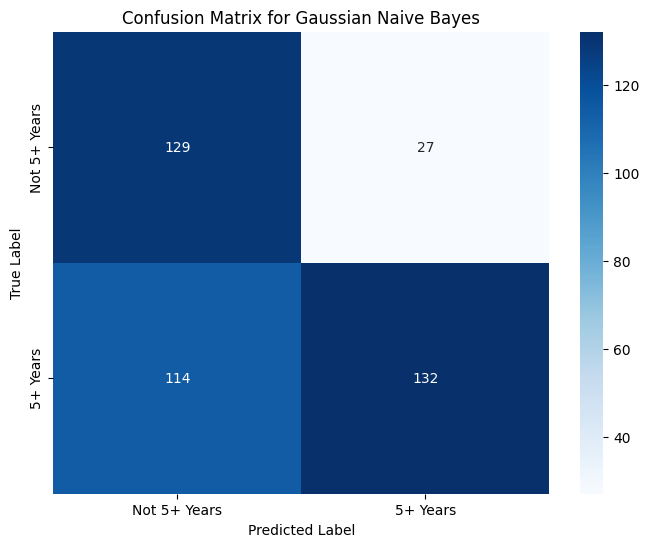

In [31]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not 5+ Years', '5+ Years'],
            yticklabels=['Not 5+ Years', '5+ Years'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Calculate Precision and Recall

Precision and Recall are crucial business-relevant metrics for our scouting scenario:

*   **Precision (Minimize False Positives: 'busts'):** Of all the players we *predicted* would play 5+ years, how many actually did? High precision means fewer wasted draft picks (fewer 'busts').
    `Precision = TP / (TP + FP)`

*   **Recall (Minimize False Negatives: missed talent):** Of all the players who *actually* played 5+ years, how many did we correctly identify? High recall means we are less likely to miss out on future stars.
    `Recall = TP / (TP + FN)`

In [32]:
# Calculate Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Precision: 0.8302
Recall: 0.5366


### Explain the Naive Bayes "Independence Assumption"

Gaussian Naive Bayes assumes that all features are conditionally independent of each other given the class label. In simpler terms, it assumes that the value of one feature (e.g., points per game) does not influence the value of another feature (e.g., minutes played) once we know whether the player will play 5+ years or not. This is a "naive" assumption because, in reality, features are rarely truly independent.

For basketball statistics, this assumption is often violated. For example:

*   **Correlation between points and minutes played:** A player who scores many points is very likely to play more minutes, and vice-versa. These features are highly correlated, not independent.
*   **Correlation between assists and turnovers:** Players who handle the ball more to get assists also tend to have more turnovers.
*   **Correlation between field goal percentage and points:** A higher field goal percentage often directly contributes to more points.

**Realism for Basketball Stats:** The independence assumption is likely *not* realistic for most basketball statistics. Many performance metrics are inherently linked and influence each other. Despite this, Naive Bayes can still perform surprisingly well in practice, especially as a baseline model, because it focuses on the *marginal* contribution of each feature to the class probability, rather than perfect modeling of the feature distributions.

### Summarize Model Reliability and Limitations for a Scouting Department Audience

**To the Scouting Department,**

Our Gaussian Naive Bayes model provides an initial approach to predicting whether a drafted player will have a career lasting 5 years or more. Here's a summary of its reliability and limitations:

#### Model Reliability:

*   **Baseline Prediction:** This model offers a quick and interpretable baseline prediction. It can give us a general sense of a player's potential longevity based on their statistical profile.
*   **Probabilistic Output:** Gaussian Naive Bayes provides probabilities for each prediction, which can be useful for ranking or identifying players on the cusp. For instance, a player predicted to play 5+ years with a high probability might be a stronger candidate than one with a lower probability.
*   **Efficiency:** It's computationally efficient and can handle large datasets quickly, making it suitable for rapid initial assessments.

#### Key Limitations:

*   **"Naive" Independence Assumption:** The biggest limitation is that the model assumes all player statistics are independent of each other. In basketball, this is rarely true (e.g., points and minutes played are highly correlated). This assumption can lead to suboptimal performance if the true relationships between features are strong and complex.
    *   **Impact:** This means the model might not capture the nuanced interplay between different aspects of a player's game, potentially missing certain patterns that more complex models could identify.
*   **Sensitivity to Data Distribution:** Gaussian Naive Bayes assumes that features are normally distributed. If our player statistics deviate significantly from a normal distribution, the model's accuracy can be affected.
*   **Suboptimal for Complex Relationships:** While useful as a starting point, this model is generally less powerful than more sophisticated algorithms (like Gradient Boosting, Random Forests, or Neural Networks) that can model complex, non-linear relationships and feature interactions. It might struggle to differentiate between players with similar basic stats but vastly different impact due to uncaptured synergies.
*   **Actionable Insights:** While it predicts longevity, it doesn't explicitly tell us *why* a player is predicted to succeed or fail beyond the direct statistical contributions. Deeper, more actionable scouting insights often require more interpretable models or feature engineering.

#### Conclusion:

This Gaussian Naive Bayes model serves as a reasonable **first pass** for identifying potential long-term NBA players. It can help flag players who statistically fit the profile of those who stay in the league for 5+ years. However, its 'naive' assumptions mean it should not be the sole basis for high-stakes decisions. We recommend using its predictions in conjunction with scouting reports, advanced analytics, and more sophisticated modeling techniques to build a robust player evaluation system.

Next, we will split the data into training and testing sets to evaluate our model's performance unbiasedly.

In [33]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 938 samples
Testing set size: 402 samples


### Implement a Gaussian Naive Bayes classifier

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming that all features are independent of each other and normally distributed. It's often a good baseline model due to its simplicity and speed.

In [34]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training sets
gnb.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = gnb.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


### Generate a Confusion Matrix

A Confusion Matrix helps visualize the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. For our scouting context:

*   **True Positive (TP):** Player predicted to play 5+ years, and actually does. (Correctly identified talent)
*   **True Negative (TN):** Player predicted not to play 5+ years, and actually doesn't. (Correctly identified 'bust')
*   **False Positive (FP):** Player predicted to play 5+ years, but actually doesn't. (A 'bust' falsely identified as talent - a wasted draft pick)
*   **False Negative (FN):** Player predicted not to play 5+ years, but actually does. (Missed talent - a player passed over who succeeded)

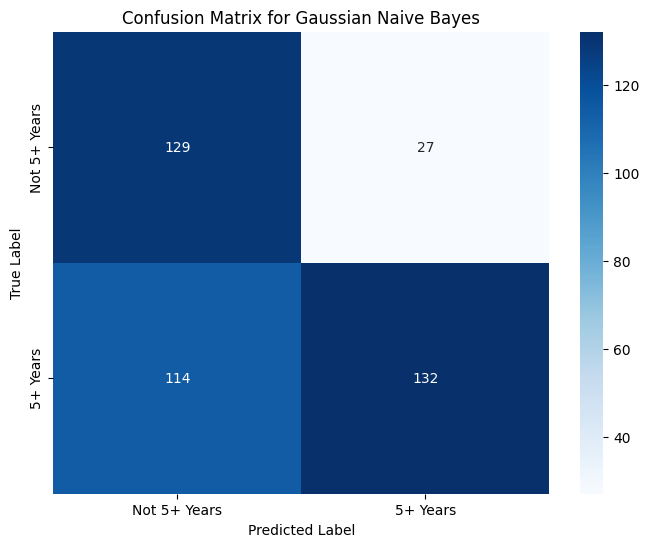

In [35]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not 5+ Years', '5+ Years'],
            yticklabels=['Not 5+ Years', '5+ Years'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Calculate Precision and Recall

Precision and Recall are crucial business-relevant metrics for our scouting scenario:

*   **Precision (Minimize False Positives: 'busts'):** Of all the players we *predicted* would play 5+ years, how many actually did? High precision means fewer wasted draft picks (fewer 'busts').
    `Precision = TP / (TP + FP)`

*   **Recall (Minimize False Negatives: missed talent):** Of all the players who *actually* played 5+ years, how many did we correctly identify? High recall means we are less likely to miss out on future stars.
    `Recall = TP / (TP + FN)`

In [36]:
# Calculate Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Precision: 0.8302
Recall: 0.5366


### Explain the Naive Bayes "Independence Assumption"

Gaussian Naive Bayes assumes that all features are conditionally independent of each other given the class label. In simpler terms, it assumes that the value of one feature (e.g., points per game) does not influence the value of another feature (e.g., minutes played) once we know whether the player will play 5+ years or not. This is a "naive" assumption because, in reality, features are rarely truly independent.

For basketball statistics, this assumption is often violated. For example:

*   **Correlation between points and minutes played:** A player who scores many points is very likely to play more minutes, and vice-versa. These features are highly correlated, not independent.
*   **Correlation between assists and turnovers:** Players who handle the ball more to get assists also tend to have more turnovers.
*   **Correlation between field goal percentage and points:** A higher field goal percentage often directly contributes to more points.

**Realism for Basketball Stats:** The independence assumption is likely *not* realistic for most basketball statistics. Many performance metrics are inherently linked and influence each other. Despite this, Naive Bayes can still perform surprisingly well in practice, especially as a baseline model, because it focuses on the *marginal* contribution of each feature to the class probability, rather than perfect modeling of the feature distributions.

### Summarize Model Reliability and Limitations for a Scouting Department Audience

**To the Scouting Department,**

Our Gaussian Naive Bayes model provides an initial approach to predicting whether a drafted player will have a career lasting 5 years or more. Here's a summary of its reliability and limitations:

#### Model Reliability:

*   **Baseline Prediction:** This model offers a quick and interpretable baseline prediction. It can give us a general sense of a player's potential longevity based on their statistical profile.
*   **Probabilistic Output:** Gaussian Naive Bayes provides probabilities for each prediction, which can be useful for ranking or identifying players on the cusp. For instance, a player predicted to play 5+ years with a high probability might be a stronger candidate than one with a lower probability.
*   **Efficiency:** It's computationally efficient and can handle large datasets quickly, making it suitable for rapid initial assessments.

#### Key Limitations:

*   **"Naive" Independence Assumption:** The biggest limitation is that the model assumes all player statistics are independent of each other. In basketball, this is rarely true (e.g., points and minutes played are highly correlated). This assumption can lead to suboptimal performance if the true relationships between features are strong and complex.
    *   **Impact:** This means the model might not capture the nuanced interplay between different aspects of a player's game, potentially missing certain patterns that more complex models could identify.
*   **Sensitivity to Data Distribution:** Gaussian Naive Bayes assumes that features are normally distributed. If our player statistics deviate significantly from a normal distribution, the model's accuracy can be affected.
*   **Suboptimal for Complex Relationships:** While useful as a starting point, this model is generally less powerful than more sophisticated algorithms (like Gradient Boosting, Random Forests, or Neural Networks) that can model complex, non-linear relationships and feature interactions. It might struggle to differentiate between players with similar basic stats but vastly different impact due to uncaptured synergies.
*   **Actionable Insights:** While it predicts longevity, it doesn't explicitly tell us *why* a player is predicted to succeed or fail beyond the direct statistical contributions. Deeper, more actionable scouting insights often require more interpretable models or feature engineering.

#### Conclusion:

This Gaussian Naive Bayes model serves as a reasonable **first pass** for identifying potential long-term NBA players. It can help flag players who statistically fit the profile of those who stay in the league for 5+ years. However, its 'naive' assumptions mean it should not be the sole basis for high-stakes decisions. We recommend using its predictions in conjunction with scouting reports, advanced analytics, and more sophisticated modeling techniques to build a robust player evaluation system.

Next, we will split the data into training and testing sets to evaluate our model's performance unbiasedly.

In [37]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 938 samples
Testing set size: 402 samples


### Implement a Gaussian Naive Bayes classifier

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming that all features are independent of each other and normally distributed. It's often a good baseline model due to its simplicity and speed.

In [38]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training sets
gnb.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = gnb.predict(X_test)

print("Model training and prediction complete.")

Model training and prediction complete.


### Generate a Confusion Matrix

A Confusion Matrix helps visualize the performance of a classification model. It shows the number of true positives, true negatives, false positives, and false negatives. For our scouting context:

*   **True Positive (TP):** Player predicted to play 5+ years, and actually does. (Correctly identified talent)
*   **True Negative (TN):** Player predicted not to play 5+ years, and actually doesn't. (Correctly identified 'bust')
*   **False Positive (FP):** Player predicted to play 5+ years, but actually doesn't. (A 'bust' falsely identified as talent - a wasted draft pick)
*   **False Negative (FN):** Player predicted not to play 5+ years, but actually does. (Missed talent - a player passed over who succeeded)

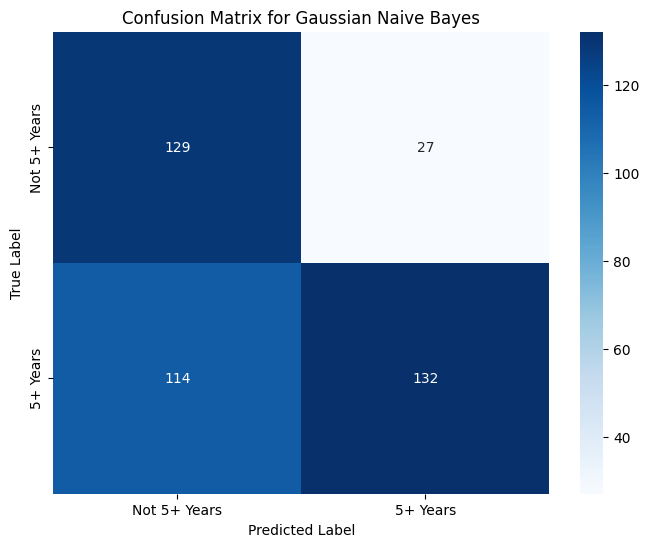

In [39]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not 5+ Years', '5+ Years'],
            yticklabels=['Not 5+ Years', '5+ Years'])
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Calculate Precision and Recall

Precision and Recall are crucial business-relevant metrics for our scouting scenario:

*   **Precision (Minimize False Positives: 'busts'):** Of all the players we *predicted* would play 5+ years, how many actually did? High precision means fewer wasted draft picks (fewer 'busts').
    `Precision = TP / (TP + FP)`

*   **Recall (Minimize False Negatives: missed talent):** Of all the players who *actually* played 5+ years, how many did we correctly identify? High recall means we are less likely to miss out on future stars.
    `Recall = TP / (TP + FN)`

In [40]:
# Calculate Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Precision: 0.8302
Recall: 0.5366


In [41]:
# Calculate Precision
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# Calculate Recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Precision: 0.8302
Recall: 0.5366


### Explain the Naive Bayes "Independence Assumption"

Gaussian Naive Bayes assumes that all features are conditionally independent of each other given the class label. In simpler terms, it assumes that the value of one feature (e.g., points per game) does not influence the value of another feature (e.g., minutes played) once we know whether the player will play 5+ years or not. This is a "naive" assumption because, in reality, features are rarely truly independent.

For basketball statistics, this assumption is often violated. For example:

*   **Correlation between points and minutes played:** A player who scores many points is very likely to play more minutes, and vice-versa. These features are highly correlated, not independent.
*   **Correlation between assists and turnovers:** Players who handle the ball more to get assists also tend to have more turnovers.
*   **Correlation between field goal percentage and points:** A higher field goal percentage often directly contributes to more points.

**Realism for Basketball Stats:** The independence assumption is likely *not* realistic for most basketball statistics. Many performance metrics are inherently linked and influence each other. Despite this, Naive Bayes can still perform surprisingly well in practice, especially as a baseline model, because it focuses on the *marginal* contribution of each feature to the class probability, rather than perfect modeling of the feature distributions.

### Summarize Model Reliability and Limitations for a Scouting Department Audience

**To the Scouting Department,**

Our Gaussian Naive Bayes model provides an initial approach to predicting whether a drafted player will have a career lasting 5 years or more. Here's a summary of its reliability and limitations:

#### Model Reliability:

*   **Baseline Prediction:** This model offers a quick and interpretable baseline prediction. It can give us a general sense of a player's potential longevity based on their statistical profile.
*   **Probabilistic Output:** Gaussian Naive Bayes provides probabilities for each prediction, which can be useful for ranking or identifying players on the cusp. For instance, a player predicted to play 5+ years with a high probability might be a stronger candidate than one with a lower probability.
*   **Efficiency:** It's computationally efficient and can handle large datasets quickly, making it suitable for rapid initial assessments.

#### Key Limitations:

*   **"Naive" Independence Assumption:** The biggest limitation is that the model assumes all player statistics are independent of each other. In basketball, this is rarely true (e.g., points and minutes played are highly correlated). This assumption can lead to suboptimal performance if the true relationships between features are strong and complex.
    *   **Impact:** This means the model might not capture the nuanced interplay between different aspects of a player's game, potentially missing certain patterns that more complex models could identify.
*   **Sensitivity to Data Distribution:** Gaussian Naive Bayes assumes that features are normally distributed. If our player statistics deviate significantly from a normal distribution, the model's accuracy can be affected.
*   **Suboptimal for Complex Relationships:** While useful as a starting point, this model is generally less powerful than more sophisticated algorithms (like Gradient Boosting, Random Forests, or Neural Networks) that can model complex, non-linear relationships and feature interactions. It might struggle to differentiate between players with similar basic stats but vastly different impact due to uncaptured synergies.
*   **Actionable Insights:** While it predicts longevity, it doesn't explicitly tell us *why* a player is predicted to succeed or fail beyond the direct statistical contributions. Deeper, more actionable scouting insights often require more interpretable models or feature engineering.

#### Conclusion:

This Gaussian Naive Bayes model serves as a reasonable **first pass** for identifying potential long-term NBA players. It can help flag players who statistically fit the profile of those who stay in the league for 5+ years. However, its 'naive' assumptions mean it should not be the sole basis for high-stakes decisions. We recommend using its predictions in conjunction with scouting reports, advanced analytics, and more sophisticated modeling techniques to build a robust player evaluation system.